Training the Model  
Approach: Transfer Learning Using MobileNetV2

In [ ]:
# !pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

IMG_SIZE = 224

# Load the "Base" Model (MobileNetV2)
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the Base Model
base_model.trainable = False

# Build the Final Model
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

# Compile the Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Loading Training Dataset

In [ ]:
# Loading and Training Script
train_ds = tf.keras.utils.image_dataset_from_directory(
    './train',
    validation_split=0.2,   # Use 20% for validation (checking the model's progress)
    subset="training",      # This creates the Training set
    seed=123,               
    image_size=(224, 224),  
    batch_size=32           
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    './train',
    validation_split=0.2,
    subset="validation",    # This creates the Validation set
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

# Speed up the loading (Autotuning)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


Found 1793 files belonging to 2 classes.
Using 1435 files for training.
Found 1793 files belonging to 2 classes.
Using 358 files for validation.


In [ ]:
# Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# Class weights based on original real-image counts after test split
# fire=393, smoke=158 (before augmentation to 1000/1000)
# real_counts = {'fire': 393, 'smoke': 158}
# total = real_counts['fire'] + real_counts['smoke']
# num_classes = 2

# image_dataset_from_directory sorts class names alphabetically -> ['fire', 'smoke']
# class_weights = {
#     0: total / (num_classes * real_counts['fire']),
#     1: total / (num_classes * real_counts['smoke'])
# }
# print('Class weights:', class_weights)

# Train the Model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping],
    # class_weight=class_weights
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 28s 527ms/step - accuracy: 0.5861 - loss: 0.7840 - val_accuracy: 0.7933 - val_loss: 0.4810
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 437ms/step - accuracy: 0.7045 - loss: 0.5700 - val_accuracy: 0.8324 - val_loss: 0.4025
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 440ms/step - accuracy: 0.7652 - loss: 0.4926 - val_accuracy: 0.8352 - val_loss: 0.3737
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 441ms/step - accuracy: 0.7833 - loss: 0.4695 - val_accuracy: 0.8547 - val_loss: 0.3473
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 441ms/step - accuracy: 0.7916 - loss: 0.4401 - val_accuracy: 0.8687 - val_loss: 0.3343
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 438ms/step - accuracy: 0.8007 - loss: 0.4309 - val_accuracy: 0.8659 - val_loss: 0.3276
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 21s 468ms/step - accuracy: 0.8216 - loss: 0.4010 - val_accuracy: 0.8827 - val_loss: 0.3092
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 441ms/step - accuracy: 0.8195 - loss: 0.3993 - val_accu

In [4]:
# Stage 2: Fine-tune only the top of MobileNetV2 for this dataset
base_model.trainable = True

# Keep most pretrained layers frozen; unfreeze only the last 40 layers
fine_tune_at = len(base_model.layers) - 40
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

print(f'Total base layers: {len(base_model.layers)}')
print(f'Fine-tuning from layer index: {fine_tune_at}')

# Recompile with a low LR to avoid destroying pretrained features
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

fine_tune_epochs = 5
total_epochs = len(history.history['loss']) + fine_tune_epochs

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=len(history.history['loss']),
    callbacks=[early_stopping],
    # class_weight=class_weights
)

Total base layers: 154
Fine-tuning from layer index: 114
Epoch 11/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 35s 584ms/step - accuracy: 0.7477 - loss: 0.5475 - val_accuracy: 0.8911 - val_loss: 0.2866
Epoch 12/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 25s 551ms/step - accuracy: 0.7972 - loss: 0.4440 - val_accuracy: 0.8939 - val_loss: 0.2866
Epoch 13/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 25s 554ms/step - accuracy: 0.8530 - loss: 0.3383 - val_accuracy: 0.8994 - val_loss: 0.2892
Epoch 14/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 25s 554ms/step - accuracy: 0.8739 - loss: 0.3057 - val_accuracy: 0.8911 - val_loss: 0.2892


Visualization

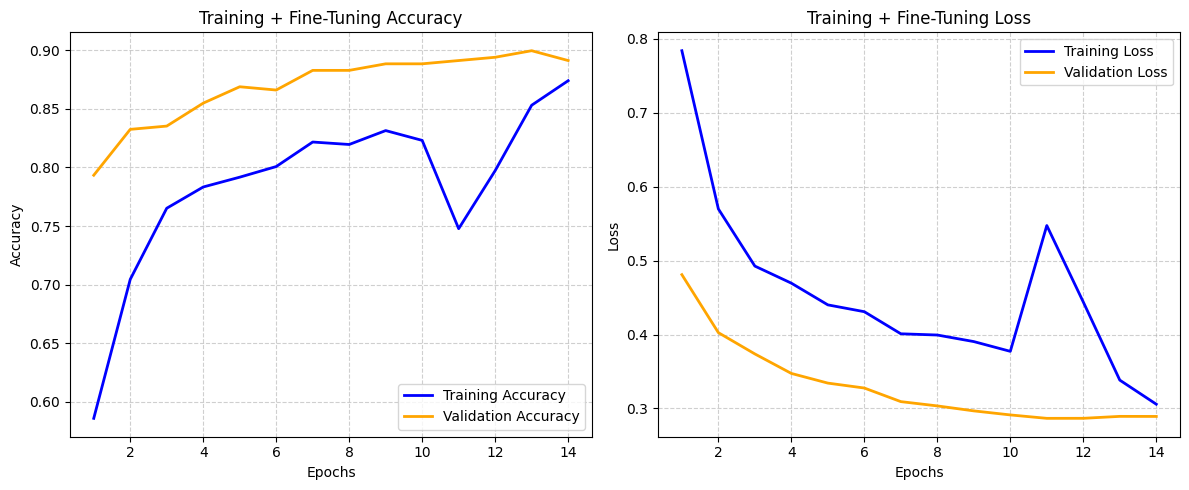

In [6]:
# Combine Stage 1 training + Stage 2 fine-tuning metrics
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

if 'history_ft' in globals():
    acc = acc + history_ft.history['accuracy']
    val_acc = val_acc + history_ft.history['val_accuracy']
    loss = loss + history_ft.history['loss']
    val_loss = val_loss + history_ft.history['val_loss']

epochs_range = range(1, len(acc) + 1)

# Create the Figure
plt.figure(figsize=(12, 5))

# Plot 1: Accuracy (Higher is better)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', color='blue', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Training + Fine-Tuning Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Loss (Lower is better)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', color='blue', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linewidth=2)
plt.title('Training + Fine-Tuning Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Loading Test Dataset

In [7]:
# Load the 100 images we moved to 'data/test' at the very start
test_ds = tf.keras.utils.image_dataset_from_directory(
    './test',
    image_size=(224, 224),
    batch_size=32
)

# The "Final Exam" - it returns [loss, accuracy]
results = model.evaluate(test_ds)
print(f"Test Accuracy: {results[1]*100:.2f}%")

Found 97 files belonging to 2 classes.


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 246ms/step - accuracy: 0.7216 - loss: 0.5400
Test Accuracy: 72.16%


Confusion Matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


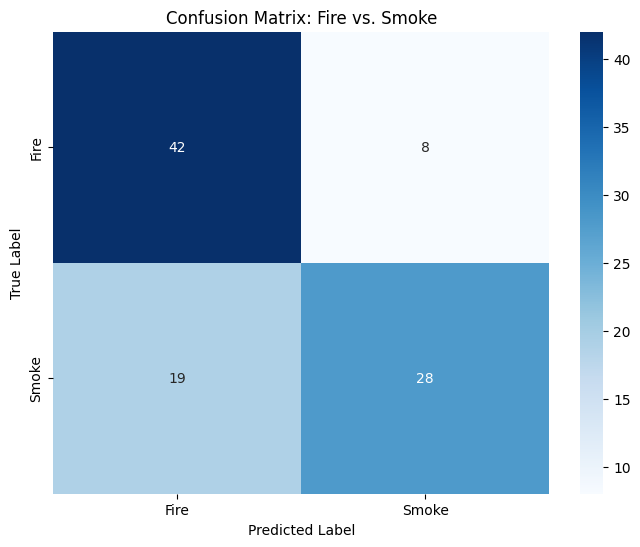

              precision    recall  f1-score   support

        Fire       0.69      0.84      0.76        50
       Smoke       0.78      0.60      0.67        47

    accuracy                           0.72        97
   macro avg       0.73      0.72      0.72        97
weighted avg       0.73      0.72      0.72        97



In [8]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Get the True Labels and Model Predictions
# We'll use the test_ds (the 100 "Final Exam" images)
all_labels = []
all_preds = []

for images, labels in test_ds:
    # Predict the batch
    preds = model.predict(images)

    # Convert sigmoid probabilities (0.0 to 1.0) to hard classes (0 or 1)
    # If pred > 0.5, it's Class 1, else Class 0
    preds_hard = (preds > 0.5).astype(int)

    all_labels.extend(labels.numpy())
    all_preds.extend(preds_hard.flatten())

# 2. Calculate the Matrix
cm = confusion_matrix(all_labels, all_preds)

# 3. Visualize with Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Fire', 'Smoke'],
            yticklabels=['Fire', 'Smoke'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Fire vs. Smoke')
plt.show()

# 4. Print the Detailed Report (Precision, Recall, F1-Score)
print(classification_report(all_labels, all_preds, target_names=['Fire', 'Smoke']))

In [9]:
#Save the model
model.save('./model/fire_smoke4.keras')